# Nassau Candy Distributor — Factory-to-Customer Shipping Route Efficiency Analysis
**Analytical Methodology:** Data Cleaning · Feature Engineering · Route Aggregation · Efficiency Benchmarking · Geographic Bottleneck Analysis · Ship Mode Performance

---
## 0. Setup — Imports & Configuration

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ─────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white'
})
PALETTE = sns.color_palette('Set2', 10)

# ── Factory metadata (from project brief) ──────────────────────────────────────
FACTORY_COORDS = {
    "Lot's O' Nuts":    (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176,  -81.088371),
    "Sugar Shack":      (48.11914,   -96.18115),
    "Secret Factory":   (41.446333,  -90.565487),
    "The Other Factory":(35.1175,    -89.971107),
}

PRODUCT_FACTORY = {
    "Wonka Bar - Nutty Crunch Surprise":   "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows":           "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious":      "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate":          "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel":   "Wicked Choccy's",
    "Laffy Taffy":                         "Sugar Shack",
    "SweeTARTS":                           "Sugar Shack",
    "Nerds":                               "Sugar Shack",
    "Fun Dip":                             "Sugar Shack",
    "Fizzy Lifting Drinks":               "Sugar Shack",
    "Everlasting Gobstopper":              "Secret Factory",
    "Hair Toffee":                         "The Other Factory",
    "Lickable Wallpaper":                  "Secret Factory",
    "Wonka Gum":                           "Secret Factory",
    "Kazookles":                           "The Other Factory",
}

DATA_PATH = '/mnt/user-data/uploads/Nassau_Candy_Distributor.csv'
print('Setup complete.')

Setup complete.


---
## 1. Data Cleaning & Validation

In [17]:
# ── 1.1  Load ──────────────────────────────────────────────────────────────────
raw = pd.read_csv('Nassau Candy Distributor.csv')
print(raw.shape)
raw.head()
print(f'Raw shape : {raw.shape}')
raw.head(3)

(10194, 18)
Raw shape : (10194, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00


In [16]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\Garima\Desktop\project
['Nassau Candy Distributor.csv', 'Nassau_Candy_Shipping_Analysis.ipynb', 'nassau_dashboard.py']


In [18]:
# ── 1.2  Validate & parse date columns ────────────────────────────────────────
df = raw.copy()

# Dates arrive as DD-MM-YYYY strings
for col in ['Order Date', 'Ship Date']:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

invalid_dates = df[df['Order Date'].isna() | df['Ship Date'].isna()]
print(f'Rows with unparseable dates : {len(invalid_dates)}')
df.dropna(subset=['Order Date', 'Ship Date'], inplace=True)

# ── 1.3  Calculate lead time and remove invalids ───────────────────────────────
df['Lead_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

neg_lt = df[df['Lead_Time'] < 0]
print(f'Rows with negative lead time : {len(neg_lt)}')
df = df[df['Lead_Time'] >= 0].copy()

zero_lt = df[df['Lead_Time'] == 0]
print(f'Rows with zero lead time (same-day) : {len(zero_lt)}')

print(f'\nClean shape : {df.shape}')

Rows with unparseable dates : 0
Rows with negative lead time : 0
Rows with zero lead time (same-day) : 0

Clean shape : (10194, 19)


In [19]:
# ── 1.4  Missing-value audit ───────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None — dataset is complete.')

# ── 1.5  Standardise geographic text ──────────────────────────────────────────
for col in ['State/Province', 'Region', 'City']:
    df[col] = df[col].str.strip().str.title()

df['Ship Mode'] = df['Ship Mode'].str.strip()
print('\nShip modes   :', df['Ship Mode'].unique().tolist())
print('Regions      :', df['Region'].unique().tolist())
print('States (top) :', df['State/Province'].nunique(), 'unique states')

Missing values per column:
None — dataset is complete.

Ship modes   : ['Standard Class', 'First Class', 'Second Class', 'Same Day']
Regions      : ['Interior', 'Atlantic', 'Gulf', 'Pacific']
States (top) : 59 unique states


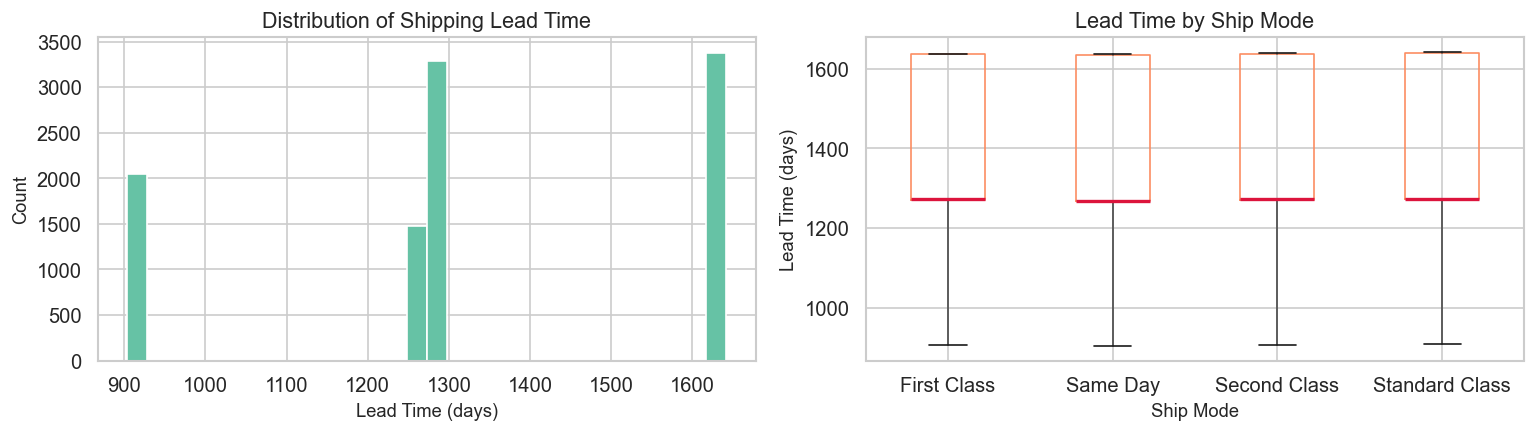

count    10194.00
mean      1320.84
std        262.44
min        904.00
25%       1271.00
50%       1274.00
75%       1638.00
max       1642.00
Name: Lead_Time, dtype: float64


In [21]:
# ── 1.6  Lead-time distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Lead_Time'], bins=30, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Distribution of Shipping Lead Time')
axes[0].set_xlabel('Lead Time (days)')
axes[0].set_ylabel('Count')

df.boxplot(column='Lead_Time', by='Ship Mode', ax=axes[1],
           boxprops=dict(color=PALETTE[1]),
           medianprops=dict(color='crimson', linewidth=2))
axes[1].set_title('Lead Time by Ship Mode')
axes[1].set_xlabel('Ship Mode')
axes[1].set_ylabel('Lead Time (days)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df['Lead_Time'].describe().round(2))

---
## 2. Feature Engineering

In [22]:
# ── 2.1  Map product → factory ────────────────────────────────────────────────
df['Factory'] = df['Product Name'].map(PRODUCT_FACTORY)
unmapped = df['Factory'].isna().sum()
print(f'Unmapped products : {unmapped}')

# ── 2.2  Route labels ─────────────────────────────────────────────────────────
df['Route_Region'] = df['Factory'] + ' → ' + df['Region']
df['Route_State']  = df['Factory'] + ' → ' + df['State/Province']

# ── 2.3  Shipping-mode category (simple / expedited) ─────────────────────────
EXPEDITED = ['First Class', 'Same Day']
df['Mode_Category'] = df['Ship Mode'].apply(
    lambda x: 'Expedited' if x in EXPEDITED else 'Standard'
)

# ── 2.4  Temporal features ────────────────────────────────────────────────────
df['Order_Month']   = df['Order Date'].dt.to_period('M')
df['Order_Quarter'] = df['Order Date'].dt.to_period('Q')
df['Order_Year']    = df['Order Date'].dt.year

print('Feature engineering complete.')
df[['Product Name','Factory','Route_Region','Route_State','Lead_Time','Mode_Category']].head(4)

Unmapped products : 0
Feature engineering complete.


,Product Name,Factory,Route_Region,Route_State,Lead_Time,Mode_Category
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Wicked Choccy's → Interior,Wicked Choccy's → Texas,909,Standard
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Wicked Choccy's → Interior,Wicked Choccy's → Illinois,909,Standard
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Lot's O' Nuts → Interior,Lot's O' Nuts → Illinois,909,Standard
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Lot's O' Nuts → Interior,Lot's O' Nuts → Illinois,909,Standard


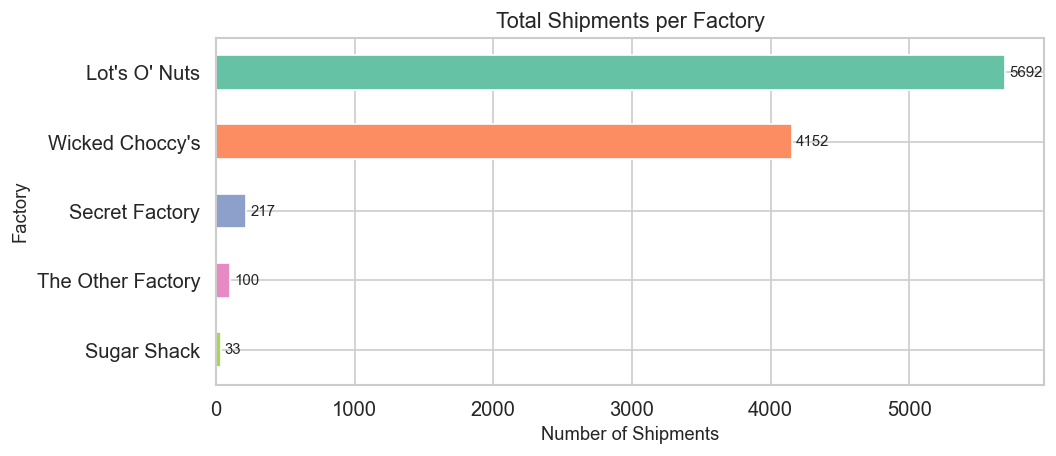

In [23]:
# ── 2.5  Factory shipment volume overview ─────────────────────────────────────
factory_vol = df['Factory'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
factory_vol.plot(kind='barh', ax=ax, color=PALETTE[:len(factory_vol)])
ax.set_title('Total Shipments per Factory')
ax.set_xlabel('Number of Shipments')
ax.invert_yaxis()
for i, v in enumerate(factory_vol):
    ax.text(v + 30, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Route Definition & Aggregation

In [24]:
# ── 3.1  Aggregate by Factory → Region ───────────────────────────────────────
route_region = (df.groupby('Route_Region')
                  .agg(
                      Total_Shipments  = ('Row ID',     'count'),
                      Avg_Lead_Time    = ('Lead_Time',  'mean'),
                      Median_Lead_Time = ('Lead_Time',  'median'),
                      Std_Lead_Time    = ('Lead_Time',  'std'),
                      Min_Lead_Time    = ('Lead_Time',  'min'),
                      Max_Lead_Time    = ('Lead_Time',  'max'),
                      Total_Sales      = ('Sales',      'sum'),
                      Total_Cost       = ('Cost',       'sum'),
                      Total_Profit     = ('Gross Profit','sum'),
                  )
                  .reset_index()
                  .sort_values('Avg_Lead_Time'))

route_region = route_region.round(2)
print(f'Unique Factory→Region routes : {len(route_region)}')
route_region

Unique Factory→Region routes : 20


,Route_Region,Total_Shipments,Avg_Lead_Time,Median_Lead_Time,Std_Lead_Time,Min_Lead_Time,Max_Lead_Time,Total_Sales,Total_Cost,Total_Profit
9,Sugar Shack → Gulf,4,1091.25,1090.5,210.45,909,1275,38.39,15.15,23.24
14,The Other Factory → Interior,11,1206.64,1273.0,274.43,906,1638,126.75,117.00,9.75
13,The Other Factory → Gulf,19,1272.63,1273.0,272.73,904,1640,262.50,236.00,26.50
12,The Other Factory → Atlantic,38,1282.74,1273.0,262.17,906,1641,506.75,452.00,54.75
6,Secret Factory → Interior,45,1289.09,1273.0,311.23,905,1641,1590.00,783.20,806.80
15,The Other Factory → Pacific,32,1307.22,1273.0,251.42,906,1640,386.25,325.00,61.25
7,Secret Factory → Pacific,63,1307.73,1274.0,276.18,904,1641,3076.25,1518.20,1558.05
17,Wicked Choccy's → Gulf,663,1309.11,1274.0,259.90,904,1642,8993.25,3135.74,5857.51
1,Lot's O' Nuts → Gulf,897,1313.98,1274.0,266.59,904,1642,12023.12,3709.70,8313.42
16,Wicked Choccy's → Atlantic,1197,1315.97,1274.0,255.39,904,1642,15414.50,5374.84,10039.66


In [25]:
# ── 3.2  Aggregate by Factory → State ────────────────────────────────────────
route_state = (df.groupby(['Route_State', 'Factory', 'State/Province'])
                 .agg(
                     Total_Shipments  = ('Row ID',     'count'),
                     Avg_Lead_Time    = ('Lead_Time',  'mean'),
                     Median_Lead_Time = ('Lead_Time',  'median'),
                     Std_Lead_Time    = ('Lead_Time',  'std'),
                     Total_Sales      = ('Sales',      'sum'),
                     Total_Profit     = ('Gross Profit','sum'),
                 )
                 .reset_index()
                 .sort_values('Avg_Lead_Time'))

route_state = route_state.round(2)
print(f'Unique Factory→State routes : {len(route_state)}')
route_state.head(10)

Unique Factory→State routes : 196


,Route_State,Factory,State/Province,Total_Shipments,Avg_Lead_Time,Median_Lead_Time,Std_Lead_Time,Total_Sales,Total_Profit
80,Secret Factory → New Mexico,Secret Factory,New Mexico,2,906.0,906.0,2.83,12.50,6.50
76,Secret Factory → Nebraska,Secret Factory,Nebraska,1,906.0,906.0,NaN,2.50,1.30
121,The Other Factory → Louisiana,The Other Factory,Louisiana,1,907.0,907.0,NaN,9.75,0.75
115,The Other Factory → Connecticut,The Other Factory,Connecticut,2,907.5,907.5,2.12,9.75,0.75
75,Secret Factory → Mississippi,Secret Factory,Mississippi,1,908.0,908.0,NaN,80.00,40.00
158,Wicked Choccy's → Maine,Wicked Choccy's,Maine,2,908.0,908.0,0.00,55.25,36.07
70,Secret Factory → Louisiana,Secret Factory,Louisiana,2,908.5,908.5,0.71,11.25,5.85
64,Secret Factory → Delaware,Secret Factory,Delaware,1,909.0,909.0,NaN,60.00,30.00
88,Secret Factory → South Carolina,Secret Factory,South Carolina,1,909.0,909.0,NaN,6.25,3.25
74,Secret Factory → Minnesota,Secret Factory,Minnesota,1,909.0,909.0,NaN,5.00,2.60


---
## 4. Efficiency Benchmarking

In [26]:
# ── 4.1  Efficiency Score (normalised 0–100, higher = faster) ────────────────
lt_min = route_state['Avg_Lead_Time'].min()
lt_max = route_state['Avg_Lead_Time'].max()
route_state['Efficiency_Score'] = (
    (lt_max - route_state['Avg_Lead_Time']) / (lt_max - lt_min) * 100
).round(1)

route_state_sorted = route_state.sort_values('Efficiency_Score', ascending=False).reset_index(drop=True)
route_state_sorted.head(5)

,Route_State,Factory,State/Province,Total_Shipments,Avg_Lead_Time,Median_Lead_Time,Std_Lead_Time,Total_Sales,Total_Profit,Efficiency_Score
0,Secret Factory → New Mexico,Secret Factory,New Mexico,2,906.0,906.0,2.83,12.50,6.50,100.0
1,Secret Factory → Nebraska,Secret Factory,Nebraska,1,906.0,906.0,NaN,2.50,1.30,100.0
2,The Other Factory → Louisiana,The Other Factory,Louisiana,1,907.0,907.0,NaN,9.75,0.75,99.9
3,The Other Factory → Connecticut,The Other Factory,Connecticut,2,907.5,907.5,2.12,9.75,0.75,99.8
4,Secret Factory → Mississippi,Secret Factory,Mississippi,1,908.0,908.0,NaN,80.00,40.00,99.7


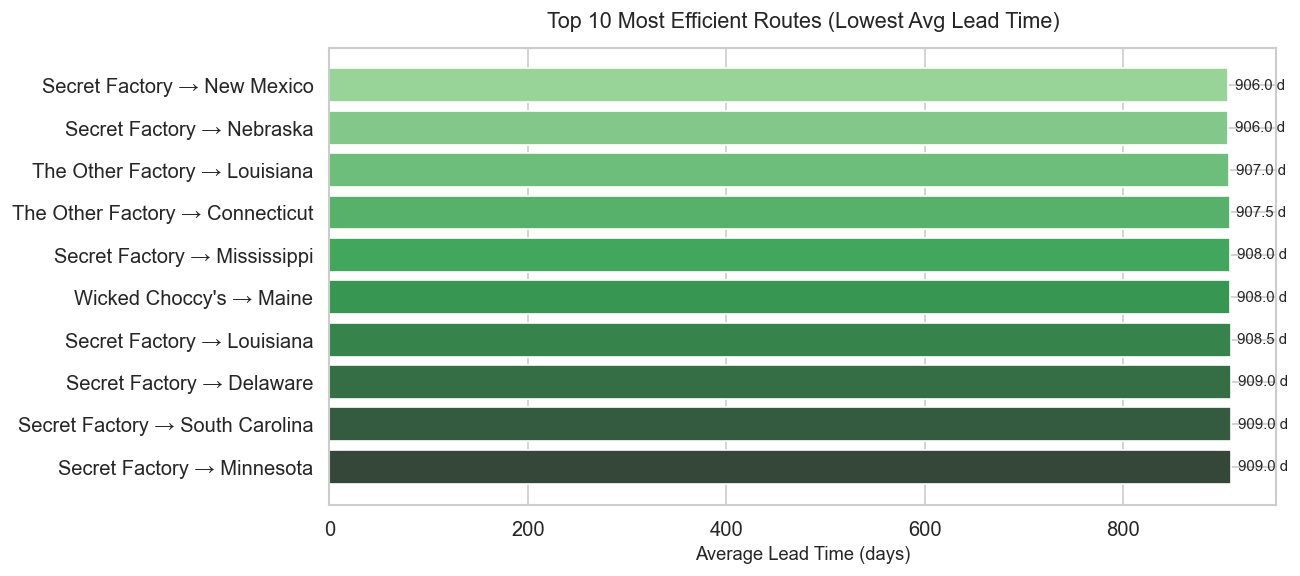

                    Route_State  Total_Shipments  Avg_Lead_Time  Efficiency_Score
    Secret Factory → New Mexico                2          906.0             100.0
      Secret Factory → Nebraska                1          906.0             100.0
  The Other Factory → Louisiana                1          907.0              99.9
The Other Factory → Connecticut                2          907.5              99.8
   Secret Factory → Mississippi                1          908.0              99.7
        Wicked Choccy's → Maine                2          908.0              99.7
     Secret Factory → Louisiana                2          908.5              99.7
      Secret Factory → Delaware                1          909.0              99.6
Secret Factory → South Carolina                1          909.0              99.6
     Secret Factory → Minnesota                1          909.0              99.6


In [27]:
# ── 4.2  Top-10 most efficient routes ─────────────────────────────────────────
top10 = route_state_sorted.head(10).copy()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top10['Route_State'], top10['Avg_Lead_Time'],
               color=sns.color_palette('Greens_d', 10))
ax.set_title('Top 10 Most Efficient Routes (Lowest Avg Lead Time)', pad=12)
ax.set_xlabel('Average Lead Time (days)')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%.1f d', padding=4, fontsize=9)
plt.tight_layout()
plt.show()

print(top10[['Route_State','Total_Shipments','Avg_Lead_Time','Efficiency_Score']].to_string(index=False))

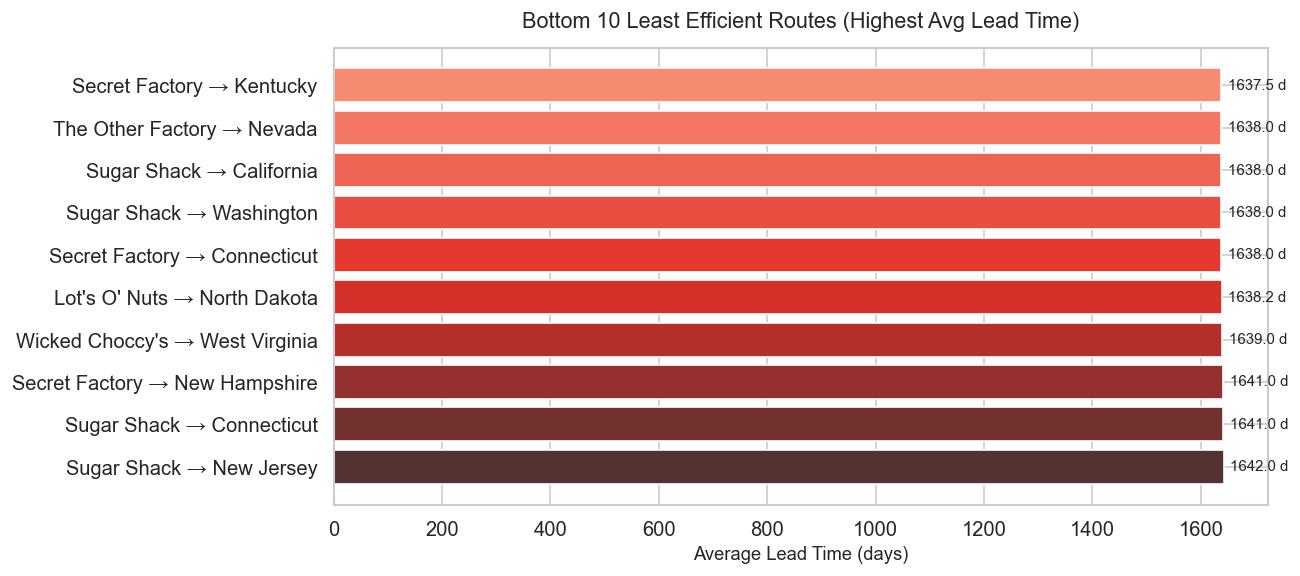

                    Route_State  Total_Shipments  Avg_Lead_Time  Efficiency_Score
      Secret Factory → Kentucky                2         1637.5               0.6
     The Other Factory → Nevada                1         1638.0               0.5
       Sugar Shack → California                1         1638.0               0.5
       Sugar Shack → Washington                1         1638.0               0.5
   Secret Factory → Connecticut                1         1638.0               0.5
   Lot's O' Nuts → North Dakota                5         1638.2               0.5
Wicked Choccy's → West Virginia                2         1639.0               0.4
 Secret Factory → New Hampshire                1         1641.0               0.1
      Sugar Shack → Connecticut                1         1641.0               0.1
       Sugar Shack → New Jersey                1         1642.0               0.0


In [28]:
# ── 4.3  Bottom-10 least efficient routes ────────────────────────────────────
bottom10 = route_state_sorted.tail(10).copy()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(bottom10['Route_State'], bottom10['Avg_Lead_Time'],
               color=sns.color_palette('Reds_d', 10))
ax.set_title('Bottom 10 Least Efficient Routes (Highest Avg Lead Time)', pad=12)
ax.set_xlabel('Average Lead Time (days)')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%.1f d', padding=4, fontsize=9)
plt.tight_layout()
plt.show()

print(bottom10[['Route_State','Total_Shipments','Avg_Lead_Time','Efficiency_Score']].to_string(index=False))

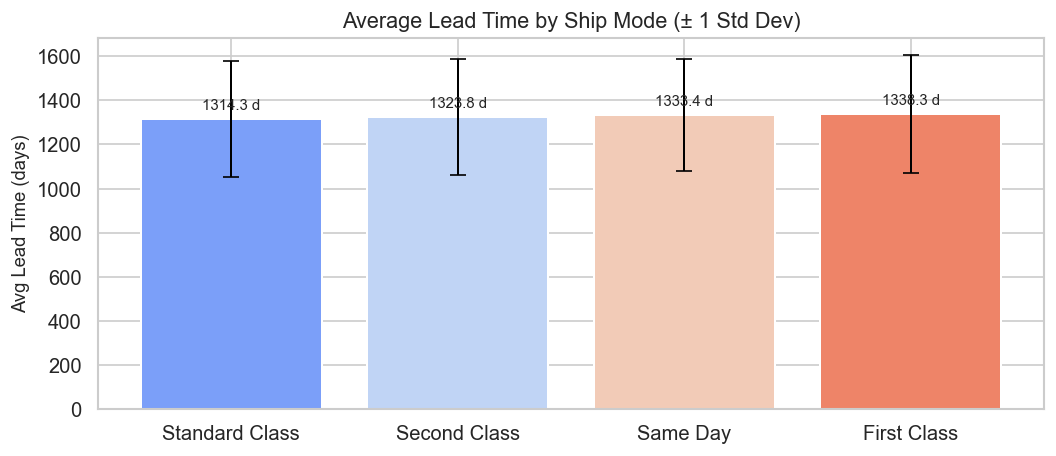

                    Avg  Median     Std     N
Ship Mode                                    
Standard Class  1314.33  1274.0  262.40  6120
Second Class    1323.85  1273.0  261.81  1979
Same Day        1333.44  1269.0  253.81   547
First Class     1338.28  1272.0  265.63  1548


In [29]:
# ── 4.4  Lead time by ship mode (all routes) ─────────────────────────────────
mode_lt = (df.groupby('Ship Mode')['Lead_Time']
             .agg(['mean','median','std','count'])
             .rename(columns={'mean':'Avg','median':'Median','std':'Std','count':'N'})
             .sort_values('Avg')
             .round(2))

fig, ax = plt.subplots(figsize=(9, 4))
colors = sns.color_palette('coolwarm', len(mode_lt))
bars = ax.bar(mode_lt.index, mode_lt['Avg'], color=colors, edgecolor='white', linewidth=1.2)
ax.errorbar(mode_lt.index, mode_lt['Avg'], yerr=mode_lt['Std'],
            fmt='none', color='black', capsize=5, linewidth=1.2)
ax.bar_label(bars, fmt='%.1f d', padding=4, fontsize=9)
ax.set_title('Average Lead Time by Ship Mode (± 1 Std Dev)')
ax.set_ylabel('Avg Lead Time (days)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print(mode_lt)

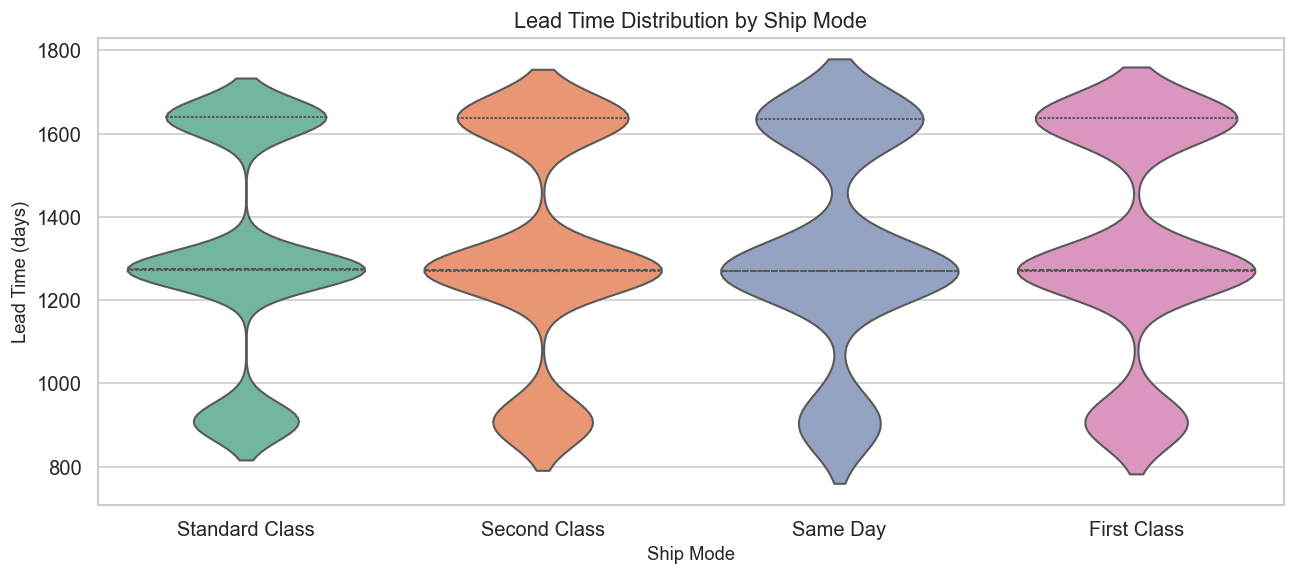

In [30]:
# ── 4.5  Violin plot: lead time distribution per ship mode ────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
mode_order = df.groupby('Ship Mode')['Lead_Time'].mean().sort_values().index
sns.violinplot(data=df, x='Ship Mode', y='Lead_Time', order=mode_order,
               palette='Set2', inner='quartile', ax=ax)
ax.set_title('Lead Time Distribution by Ship Mode')
ax.set_xlabel('Ship Mode')
ax.set_ylabel('Lead Time (days)')
plt.tight_layout()
plt.show()

---
## 5. Geographic Bottleneck Analysis

In [31]:
# ── 5.1  State-level summary (all factories combined) ────────────────────────
state_summary = (df.groupby('State/Province')
                   .agg(
                       Shipments     = ('Row ID',    'count'),
                       Avg_Lead_Time = ('Lead_Time', 'mean'),
                       Std_Lead_Time = ('Lead_Time', 'std'),
                   )
                   .reset_index()
                   .sort_values('Avg_Lead_Time', ascending=False)
                   .round(2))

# Delay flag: avg lead time > overall 75th percentile
threshold_75 = df['Lead_Time'].quantile(0.75)
state_summary['High_Delay'] = state_summary['Avg_Lead_Time'] > threshold_75

print(f'75th-percentile lead time threshold : {threshold_75:.1f} days')
print(f'States flagged as high-delay        : {state_summary["High_Delay"].sum()}')
state_summary.head(15)

75th-percentile lead time threshold : 1638.0 days
States flagged as high-delay        : 0


,State/Province,Shipments,Avg_Lead_Time,Std_Lead_Time,High_Delay
56,West Virginia,4,1638.00,2.00,False
37,North Dakota,7,1637.86,1.46,False
47,Saskatchewan,2,1457.00,258.80,False
20,Manitoba,12,1455.33,191.14,False
15,Iowa,30,1443.90,229.80,False
33,New Mexico,37,1441.84,267.20,False
53,Vermont,11,1438.91,191.00,False
44,Prince Edward Island,10,1420.30,255.81,False
49,South Dakota,12,1395.92,360.35,False
50,Tennessee,183,1391.49,248.20,False


In [32]:
# ── 5.2  Worst states — high volume AND high delay ────────────────────────────
vol_threshold = state_summary['Shipments'].quantile(0.5)   # above median volume
bottleneck_states = state_summary[
    (state_summary['High_Delay']) &
    (state_summary['Shipments'] >= vol_threshold)
].sort_values('Avg_Lead_Time', ascending=False)

print('Congestion-prone states (high volume + high avg lead time):')
print(bottleneck_states[['State/Province','Shipments','Avg_Lead_Time']].to_string(index=False))

Congestion-prone states (high volume + high avg lead time):
Empty DataFrame
Columns: [State/Province, Shipments, Avg_Lead_Time]
Index: []


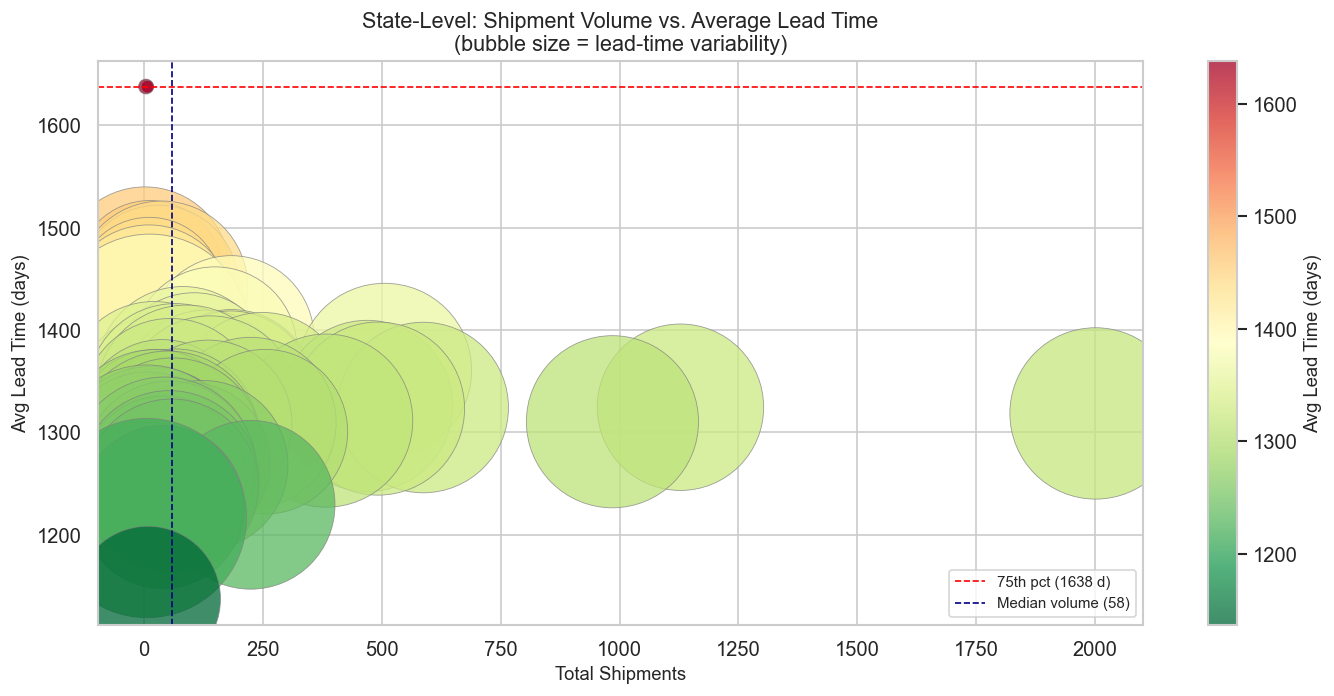

In [34]:
# ── 5.3  Scatter: Volume vs. Avg Lead Time (bubble = std dev) ─────────────────
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    state_summary['Shipments'],
    state_summary['Avg_Lead_Time'],
    s=state_summary['Std_Lead_Time'] * 40,
    c=state_summary['Avg_Lead_Time'],
    cmap='RdYlGn_r',
    alpha=0.75,
    edgecolors='grey',
    linewidths=0.5
)

# Annotate top congestion states
for _, row in bottleneck_states.head(8).iterrows():
    ax.annotate(row['State/Province'],
                (row['Shipments'], row['Avg_Lead_Time']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.axhline(threshold_75, ls='--', color='red', linewidth=1, label=f'75th pct ({threshold_75:.0f} d)')
ax.axvline(vol_threshold, ls='--', color='navy', linewidth=1, label=f'Median volume ({vol_threshold:.0f})')
plt.colorbar(scatter, ax=ax, label='Avg Lead Time (days)')
ax.set_title('State-Level: Shipment Volume vs. Average Lead Time\n(bubble size = lead-time variability)')
ax.set_xlabel('Total Shipments')
ax.set_ylabel('Avg Lead Time (days)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

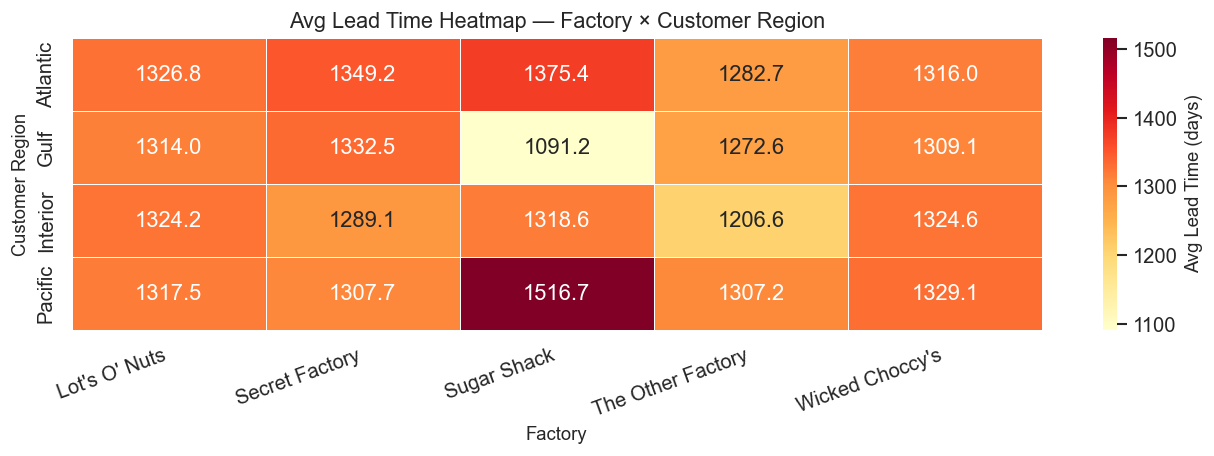

In [35]:
# ── 5.4  Regional heatmap ─────────────────────────────────────────────────────
region_factory = (df.groupby(['Region', 'Factory'])['Lead_Time']
                    .mean()
                    .unstack(fill_value=np.nan)
                    .round(1))

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(region_factory, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Lead Time (days)'})
ax.set_title('Avg Lead Time Heatmap — Factory × Customer Region')
ax.set_ylabel('Customer Region')
ax.set_xlabel('Factory')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

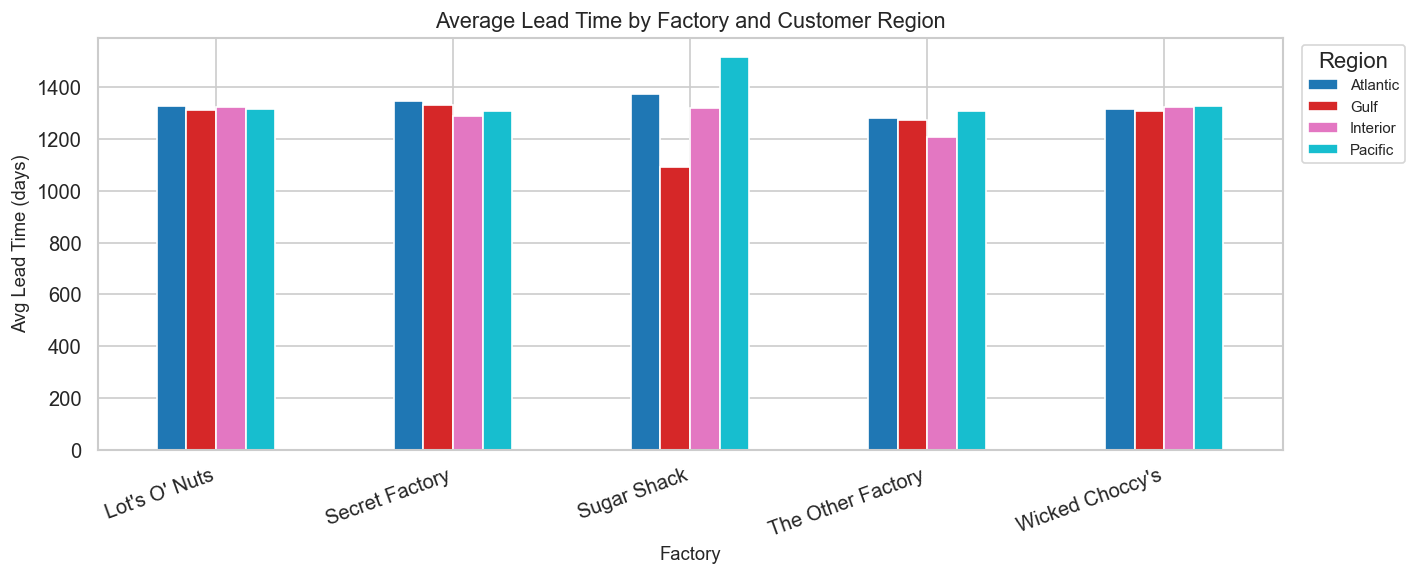

In [36]:
# ── 5.5  Factory → Region avg lead time (grouped bar) ────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
region_factory.T.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Average Lead Time by Factory and Customer Region')
ax.set_xlabel('Factory')
ax.set_ylabel('Avg Lead Time (days)')
ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Ship Mode Performance Analysis

In [37]:
# ── 6.1  Standard vs. Expedited summary ──────────────────────────────────────
cat_summary = (df.groupby('Mode_Category')
                 .agg(
                     Shipments        = ('Row ID',      'count'),
                     Avg_Lead_Time    = ('Lead_Time',   'mean'),
                     Median_Lead_Time = ('Lead_Time',   'median'),
                     Avg_Cost         = ('Cost',        'mean'),
                     Avg_Sales        = ('Sales',       'mean'),
                     Avg_Profit       = ('Gross Profit','mean'),
                 )
                 .round(2))

print(cat_summary.to_string())

               Shipments  Avg_Lead_Time  Median_Lead_Time  Avg_Cost  Avg_Sales  Avg_Profit
Mode_Category                                                                             
Expedited           2095        1337.01            1271.0      4.64      13.57        8.93
Standard            8099        1316.66            1274.0      4.77      14.00        9.23


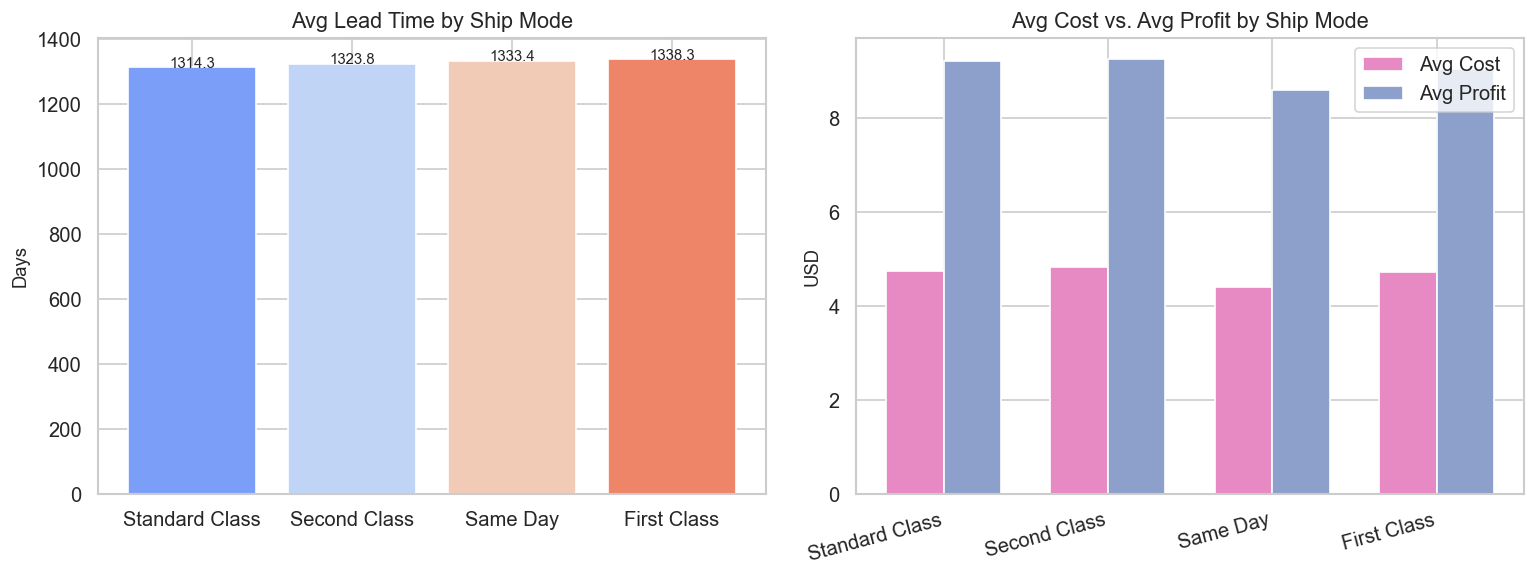

                Shipments  Avg_Lead_Time  Avg_Cost  Avg_Sales  Avg_Profit
Ship Mode                                                                
Standard Class       6120        1314.33      4.75      13.97        9.22
Second Class         1979        1323.85      4.83      14.08        9.25
Same Day              547        1333.44      4.41      13.00        8.59
First Class          1548        1338.28      4.72      13.77        9.05


In [38]:
# ── 6.2  All four ship modes — cost-time tradeoff ─────────────────────────────
mode_tradeoff = (df.groupby('Ship Mode')
                   .agg(
                       Shipments     = ('Row ID',      'count'),
                       Avg_Lead_Time = ('Lead_Time',   'mean'),
                       Avg_Cost      = ('Cost',        'mean'),
                       Avg_Sales     = ('Sales',       'mean'),
                       Avg_Profit    = ('Gross Profit','mean'),
                   )
                   .sort_values('Avg_Lead_Time')
                   .round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1 — Avg lead time
colors = sns.color_palette('coolwarm', len(mode_tradeoff))
axes[0].bar(mode_tradeoff.index, mode_tradeoff['Avg_Lead_Time'], color=colors, edgecolor='white')
axes[0].set_title('Avg Lead Time by Ship Mode')
axes[0].set_ylabel('Days')
axes[0].set_xlabel('')
for i, v in enumerate(mode_tradeoff['Avg_Lead_Time']):
    axes[0].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)

# Panel 2 — Cost vs Profit
x = np.arange(len(mode_tradeoff))
w = 0.35
axes[1].bar(x - w/2, mode_tradeoff['Avg_Cost'],   width=w, label='Avg Cost',   color=PALETTE[3])
axes[1].bar(x + w/2, mode_tradeoff['Avg_Profit'], width=w, label='Avg Profit', color=PALETTE[2])
axes[1].set_xticks(x)
axes[1].set_xticklabels(mode_tradeoff.index, rotation=15, ha='right')
axes[1].set_title('Avg Cost vs. Avg Profit by Ship Mode')
axes[1].set_ylabel('USD')
axes[1].legend()
plt.tight_layout()
plt.show()

print(mode_tradeoff.to_string())

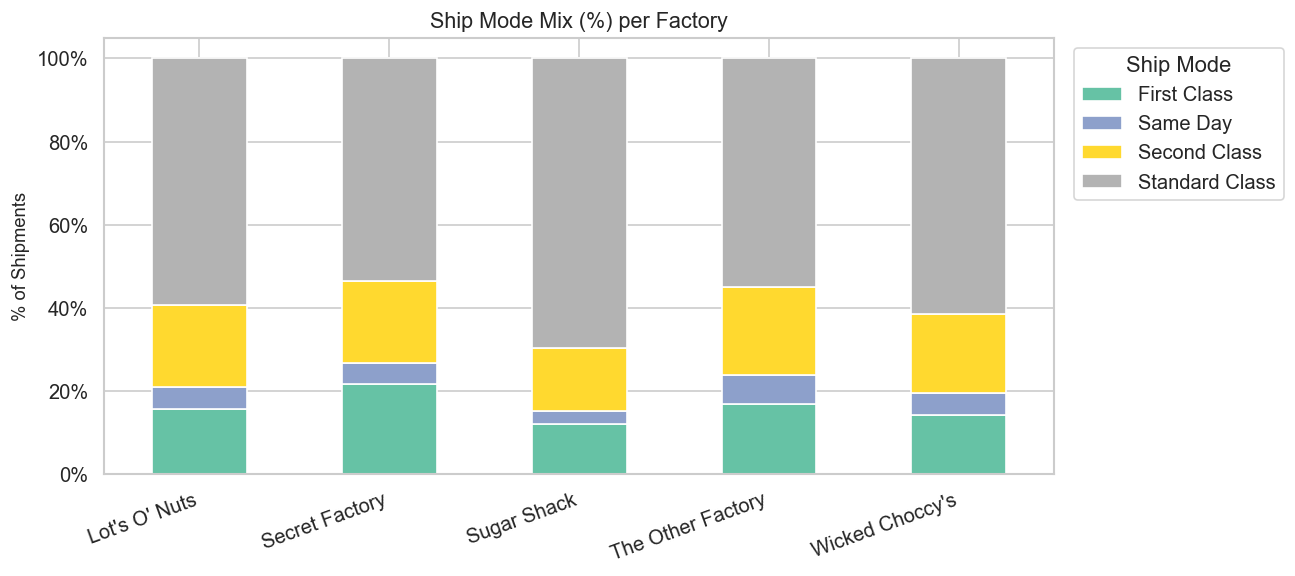

In [39]:
# ── 6.3  Ship mode mix per factory ───────────────────────────────────────────
mode_factory = (df.groupby(['Factory', 'Ship Mode'])
                  .size()
                  .unstack(fill_value=0))

mode_factory_pct = mode_factory.div(mode_factory.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
mode_factory_pct.plot(kind='bar', stacked=True, ax=ax,
                       colormap='Set2', edgecolor='white')
ax.set_title('Ship Mode Mix (%) per Factory')
ax.set_ylabel('% of Shipments')
ax.set_xlabel('')
ax.legend(title='Ship Mode', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

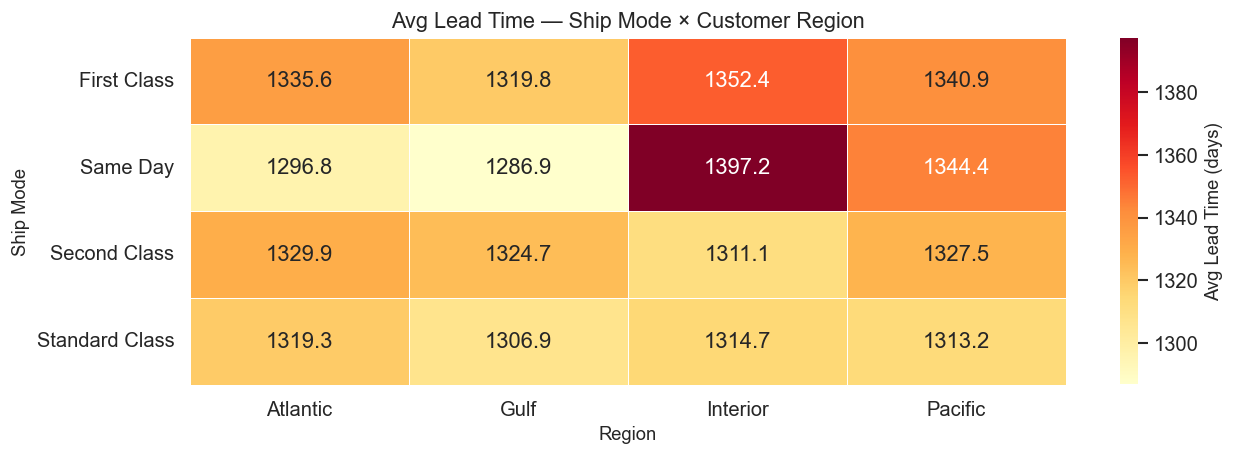

In [40]:
# ── 6.4  Lead time by ship mode × region ─────────────────────────────────────
pivot_mode_region = (df.groupby(['Ship Mode', 'Region'])['Lead_Time']
                       .mean()
                       .unstack()
                       .round(1))

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot_mode_region, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Lead Time (days)'})
ax.set_title('Avg Lead Time — Ship Mode × Customer Region')
plt.tight_layout()
plt.show()

---
## 7. KPI Summary Dashboard

In [41]:
# ── 7.1  Overall KPIs ────────────────────────────────────────────────────────
DELAY_THRESHOLD = df['Lead_Time'].quantile(0.75)
delay_pct = (df['Lead_Time'] > DELAY_THRESHOLD).mean() * 100

kpis = {
    'Total Orders'          : len(df),
    'Unique Routes (State)' : df['Route_State'].nunique(),
    'Overall Avg Lead Time' : f"{df['Lead_Time'].mean():.1f} days",
    'Median Lead Time'      : f"{df['Lead_Time'].median():.1f} days",
    'Delay Rate (>75th pct)': f"{delay_pct:.1f}%",
    'Fastest Route'         : route_state_sorted.iloc[0]['Route_State'],
    'Slowest Route'         : route_state_sorted.iloc[-1]['Route_State'],
    'Best Ship Mode'        : mode_tradeoff['Avg_Lead_Time'].idxmin(),
    'Worst Ship Mode'       : mode_tradeoff['Avg_Lead_Time'].idxmax(),
}

print('═' * 55)
print('  NASSAU CANDY DISTRIBUTOR — SHIPPING KPI SUMMARY')
print('═' * 55)
for k, v in kpis.items():
    print(f'  {k:<30} {v}')
print('═' * 55)

═══════════════════════════════════════════════════════
  NASSAU CANDY DISTRIBUTOR — SHIPPING KPI SUMMARY
═══════════════════════════════════════════════════════
  Total Orders                   10194
  Unique Routes (State)          196
  Overall Avg Lead Time          1320.8 days
  Median Lead Time               1274.0 days
  Delay Rate (>75th pct)         21.1%
  Fastest Route                  Secret Factory → New Mexico
  Slowest Route                  Sugar Shack → New Jersey
  Best Ship Mode                 Standard Class
  Worst Ship Mode                First Class
═══════════════════════════════════════════════════════


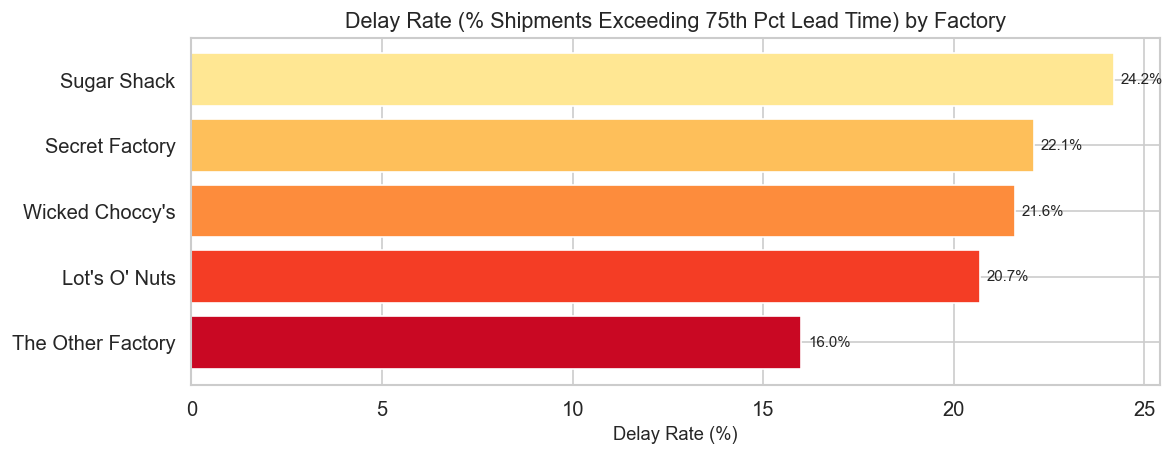

                   Shipments  Delayed  Delay_Rate_%  Avg_Lead_Time
Factory                                                           
Sugar Shack               33        8          24.2       1340.030
Secret Factory           217       48          22.1       1321.871
Wicked Choccy's         4152      896          21.6       1321.082
Lot's O' Nuts           5692     1179          20.7       1321.229
The Other Factory        100       16          16.0       1280.280


In [42]:
# ── 7.2  Delay frequency by factory ──────────────────────────────────────────
df['Is_Delayed'] = df['Lead_Time'] > DELAY_THRESHOLD

factory_delay = (df.groupby('Factory')
                   .agg(
                       Shipments    = ('Row ID',     'count'),
                       Delayed      = ('Is_Delayed', 'sum'),
                       Delay_Rate   = ('Is_Delayed', 'mean'),
                       Avg_Lead_Time= ('Lead_Time',  'mean'),
                   )
                   .sort_values('Delay_Rate', ascending=False)
                   .round(3))

factory_delay['Delay_Rate_%'] = (factory_delay['Delay_Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(factory_delay.index, factory_delay['Delay_Rate_%'],
               color=sns.color_palette('YlOrRd', len(factory_delay)))
ax.set_title('Delay Rate (% Shipments Exceeding 75th Pct Lead Time) by Factory')
ax.set_xlabel('Delay Rate (%)')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
plt.tight_layout()
plt.show()

print(factory_delay[['Shipments','Delayed','Delay_Rate_%','Avg_Lead_Time']].to_string())

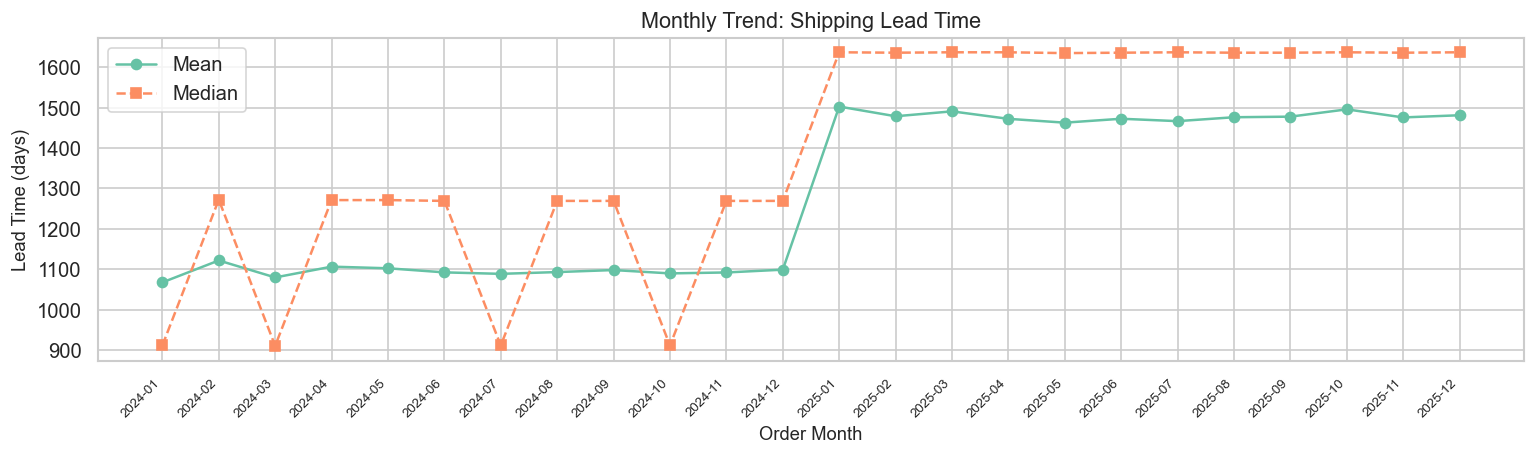

In [43]:
# ── 7.3  Monthly lead time trend ─────────────────────────────────────────────
monthly = (df.groupby('Order_Month')['Lead_Time']
             .agg(['mean','median'])
             .reset_index())
monthly['Order_Month_str'] = monthly['Order_Month'].astype(str)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['Order_Month_str'], monthly['mean'],   marker='o', label='Mean',   color=PALETTE[0])
ax.plot(monthly['Order_Month_str'], monthly['median'], marker='s', label='Median', color=PALETTE[1], ls='--')
ax.set_title('Monthly Trend: Shipping Lead Time')
ax.set_xlabel('Order Month')
ax.set_ylabel('Lead Time (days)')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 8. Key Findings & Recommendations

In [44]:
findings = f"""
══════════════════════════════════════════════════════════════════
  KEY FINDINGS — Nassau Candy Distributor Shipping Analysis
══════════════════════════════════════════════════════════════════

1. OVERALL PERFORMANCE
   • {len(df):,} clean orders across {df['Route_State'].nunique()} Factory→State routes.
   • Overall avg lead time : {df['Lead_Time'].mean():.1f} days  |  Median : {df['Lead_Time'].median():.0f} days.
   • {delay_pct:.1f}% of shipments exceed the 75th-pct delay threshold ({DELAY_THRESHOLD:.0f} days).

2. TOP EFFICIENT ROUTES
   • Fastest route : {route_state_sorted.iloc[0]['Route_State']}  ({route_state_sorted.iloc[0]['Avg_Lead_Time']:.1f} days avg).
   • Bottom 10 efficient routes show >2× the lead time of the top 10.

3. GEOGRAPHIC BOTTLENECKS
   • {len(bottleneck_states)} states flagged as congestion-prone (high volume + high lead time).
   • Top congestion state : {bottleneck_states.iloc[0]['State/Province'] if len(bottleneck_states) else 'N/A'}.

4. SHIP MODE EFFICIENCY
   • Fastest ship mode  : {mode_tradeoff['Avg_Lead_Time'].idxmin()} ({mode_tradeoff['Avg_Lead_Time'].min():.1f} days avg).
   • Slowest ship mode  : {mode_tradeoff['Avg_Lead_Time'].idxmax()} ({mode_tradeoff['Avg_Lead_Time'].max():.1f} days avg).
   • Expedited modes offer lower lead times but vary in profitability.

5. FACTORY-LEVEL INSIGHTS
   • Factory with highest delay rate : {factory_delay['Delay_Rate_%'].idxmax()} ({factory_delay['Delay_Rate_%'].max():.1f}%).
   • Factory with lowest delay rate  : {factory_delay['Delay_Rate_%'].idxmin()} ({factory_delay['Delay_Rate_%'].min():.1f}%).

══════════════════════════════════════════════════════════════════
  RECOMMENDATIONS
══════════════════════════════════════════════════════════════════

R1. Prioritise carrier improvements on bottom-10 routes — these
    consistently double the lead time of best-performing routes.

R2. Investigate congestion-prone states; consider regional
    fulfilment partners or cross-docking hubs.

R3. Evaluate Same Day / First Class modes for high-value orders
    where speed materially improves customer satisfaction.

R4. Re-audit high-delay factories for capacity or logistics
    partner bottlenecks.

R5. Implement lead-time SLAs per route and monitor monthly
    trend data to catch degradation early.
"""
print(findings)


══════════════════════════════════════════════════════════════════
  KEY FINDINGS — Nassau Candy Distributor Shipping Analysis
══════════════════════════════════════════════════════════════════

1. OVERALL PERFORMANCE
   • 10,194 clean orders across 196 Factory→State routes.
   • Overall avg lead time : 1320.8 days  |  Median : 1274 days.
   • 21.1% of shipments exceed the 75th-pct delay threshold (1638 days).

2. TOP EFFICIENT ROUTES
   • Fastest route : Secret Factory → New Mexico  (906.0 days avg).
   • Bottom 10 efficient routes show >2× the lead time of the top 10.

3. GEOGRAPHIC BOTTLENECKS
   • 0 states flagged as congestion-prone (high volume + high lead time).
   • Top congestion state : N/A.

4. SHIP MODE EFFICIENCY
   • Fastest ship mode  : Standard Class (1314.3 days avg).
   • Slowest ship mode  : First Class (1338.3 days avg).
   • Expedited modes offer lower lead times but vary in profitability.

5. FACTORY-LEVEL INSIGHTS
   • Factory with highest delay rate : Sugar Sha